In [ ]:
# HIBA ABDUL SALAM
# 33126931

In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# GitHub raw file path
base_url = "https://raw.githubusercontent.com/hiba2026-cloud/Northstar-Analytics/main/"

# Load datasets
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
customers = pd.read_csv(base_url + "customers.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")

# Display first rows
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
# Check missing values

orders.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


In [ ]:
# Summary statistics

orders.describe()

,promised_window_hours,order_value,special_handling_flag
count,1250.000000,1250.000000,1250.000000
mean,7.621600,91.050520,0.190400
std,7.057015,60.917783,0.392774
min,1.000000,2.040000,0.000000
25%,4.000000,47.915000,0.000000
50%,6.000000,76.530000,0.000000
75%,12.000000,121.097500,0.000000
max,24.000000,510.060000,1.000000


In [ ]:
# NumPy analysis

order_values = orders["order_value"]

print("Average Order Value:", np.mean(order_values))
print("Maximum Order Value:", np.max(order_values))
print("Minimum Order Value:", np.min(order_values))
print("Standard Deviation:", np.std(order_values))

Average Order Value: 91.05051999999999
Maximum Order Value: 510.06
Minimum Order Value: 2.04
Standard Deviation: 60.893411308364094


In [ ]:
# High-value orders

high_value_orders = orders[orders["order_value"] > 200]

high_value_orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
12,O00013,C0234,Retail,2024-03-29 22:11:00,24,Airport,Central,Medium,302.70,App,0
34,O00035,C0524,Business,2024-06-14 13:12:00,4,north,CENTRAL,Medium,209.07,Web,0
51,O00052,C0150,Retail,2024-08-14 08:33:00,12,north,Riverside,Medium,293.65,API,0
60,O00061,C0289,Passenger,2024-07-12 01:44:00,6,AIRPORT,north,High,238.90,Web,1
65,O00066,C0421,Passenger,2024-06-21 11:22:00,4,SOUTH,EAST,Low,237.58,App,0


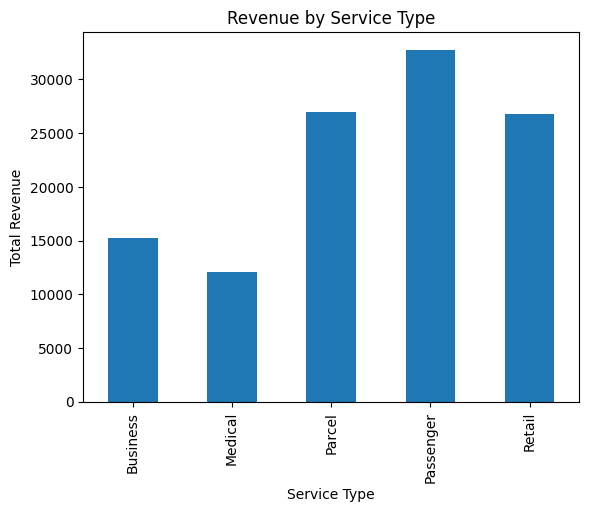

In [ ]:
# Total revenue by service type

service_revenue = orders.groupby(
    "service_type"
)["order_value"].sum()

service_revenue.plot(kind="bar")

plt.title("Revenue by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Revenue")

plt.show()

In [ ]:
# Average delivery cost by delivery status

delivery_costs = deliveries.groupby("delivery_status")["fuel_or_charge_cost"].mean()

print(delivery_costs)

delivery_status
Delayed    13.138713
Failed     13.147955
OnTime     12.678052
Name: fuel_or_charge_cost, dtype: float64


In [ ]:
# Merge orders and deliveries

merged_data = pd.merge(orders, deliveries, on="order_id")

# Failed deliveries by service type

failed_deliveries = merged_data[merged_data["delivery_status"] == "Failed"]

failed_summary = failed_deliveries.groupby("service_type")["delivery_id"].count()

print(failed_summary)

service_type
Business     25
Medical      16
Parcel       25
Passenger    38
Retail       28
Name: delivery_id, dtype: int64


In [ ]:
# Complaint channel analysis

complaint_channels = complaints.groupby("channel")["complaint_id"].count()

print(complaint_channels)

channel
App        97
Chatbot    67
Email      64
Phone      92
Name: complaint_id, dtype: int64


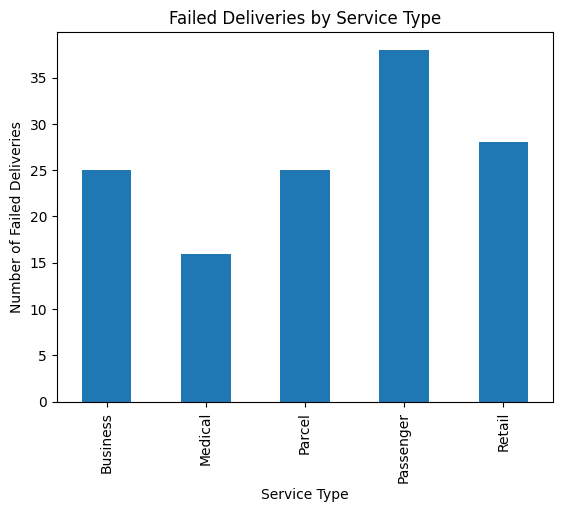

In [ ]:
# Failed deliveries chart
failed_summary.plot(kind="bar")

plt.title("Failed Deliveries by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Failed Deliveries")

plt.show()

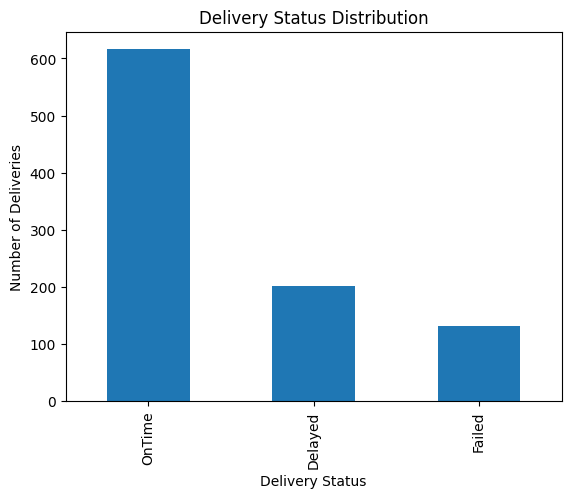

In [ ]:
import matplotlib.pyplot as plt

# Count delivery statuses

delivery_counts = deliveries["delivery_status"].value_counts()

# Create graph

delivery_counts.plot(kind='bar')

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

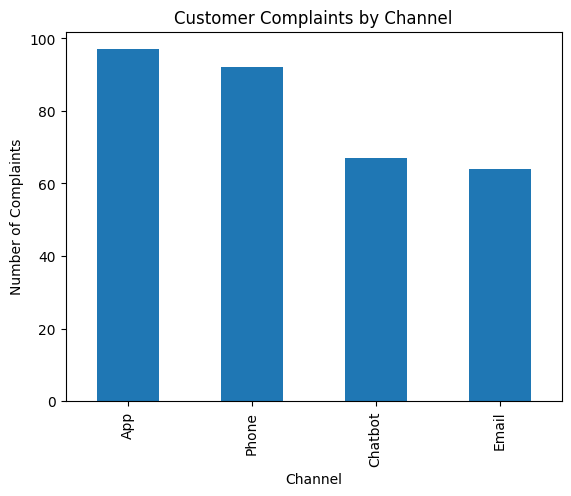

In [ ]:
# Complaint channels

complaint_channels = complaints["channel"].value_counts()

# Graph

complaint_channels.plot(kind='bar')

plt.title("Customer Complaints by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Complaints")

plt.show()